# Kwant — Theory and Practice · Chapter 9
## Chern numbers — the Thouless pump and the Haldane model

*Part II · Sections 20–21 · Figures 47–52* &nbsp;·&nbsp; [← Chapter 8](08_Topology_in_One_Dimension.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 10 →](10_Z2_and_Chiral_Superconductors.ipynb)

### In this chapter

- [20. The Thouless pump — a Chern number in (k, t)](#20.-The-Thouless-pump-—-a-Chern-number-in-(k,-t))
- [21. The Haldane model — a Chern insulator without Landau levels](#21.-The-Haldane-model-—-a-Chern-insulator-without-Landau-levels)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 47–52, so the counter starts at 46.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [46]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 20. The Thouless pump — a Chern number in (k, t)

Thouless [PRB **27**, 6083 (1983)]: slide a periodic potential adiabatically
by one period and the charge transported through a filled band is *exactly
quantized* — it is the Chern number of the band over the $(k, \varphi)$ torus,
where $\varphi$ is the pump phase.  Time acts as a second momentum: **a 1D
pump is a 2D Chern insulator in disguise**.

The minimal realization is the Rice–Mele model — an SSH chain whose
dimerization $\delta$ and staggered onsite $\Delta$ trace a loop:

$$t_{1,2} = t_0 \pm \delta_0\cos\varphi, \qquad
\Delta(\varphi) = \Delta_0 \sin\varphi .$$

The loop encircles the gapless point $(\delta, \Delta) = (0, 0)$, so $C = \pm 1$:
one electron pumped per cycle.  Three equivalent diagnostics, all computed
below:

1. the FHS Chern number on the $(k, \varphi)$ torus (this is where the
   `chern_fhs` routine used throughout Part II first appears);
2. the polarization (Zak phase) winding exactly once per cycle;
3. edge states in a finite chain traversing the gap as $\varphi$ advances —
   the real-space picture of the pumped charge.

*Experiments:* quantised Thouless pumping was finally realised three decades
after the proposal, with ultracold fermions [Nakajima *et al.*, Nat. Phys.
**12**, 296 (2016)] and bosons [Lohse *et al.*, Nat. Phys. **12**, 350
(2016)] in modulated optical superlattices; see Citro & Aidelsburger, Nat.
Rev. Phys. **5**, 87 (2023) for a review.  The same Wilson-loop
(polarization) technology used here reappears in §24 as the nested Wilson
loop of higher-order topology.


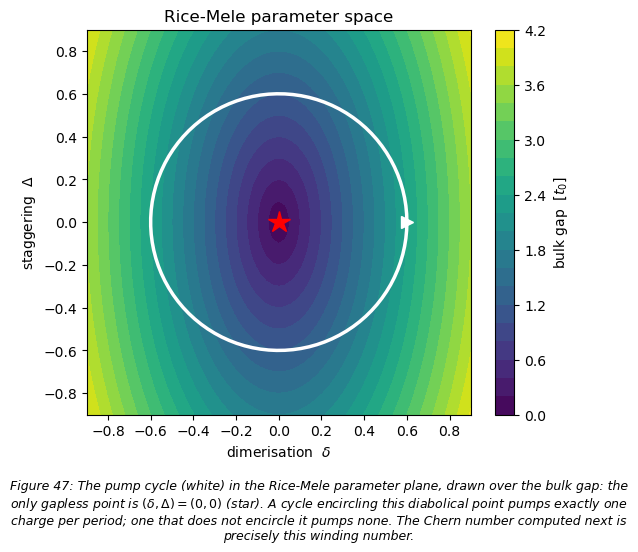

In [2]:
# --- geometry: the pump cycle in parameter space -----------------------------
import numpy as np
from matplotlib import pyplot

t0_, nk = 1.0, 121
deltas = np.linspace(-0.9, 0.9, 61)
Ds = np.linspace(-0.9, 0.9, 61)
ks = np.linspace(0, 2 * np.pi, nk)
gap = np.zeros((len(Ds), len(deltas)))
for i, D in enumerate(Ds):
    for j, de in enumerate(deltas):
        q = (t0_ + de) + (t0_ - de) * np.exp(1j * ks)
        gap[i, j] = 2 * np.min(np.sqrt(np.abs(q) ** 2 + D ** 2))
pyplot.figure(figsize=(6.2, 5))
pyplot.contourf(deltas, Ds, gap, 25, cmap='viridis')
pyplot.colorbar(label='bulk gap  $[t_0]$')
phi = np.linspace(0, 2 * np.pi, 100)
pyplot.plot(0.6 * np.cos(phi), 0.6 * np.sin(phi), 'w-', lw=2.5)
pyplot.plot([0.6], [0], 'w>', ms=9)
pyplot.plot(0, 0, 'r*', ms=16)
pyplot.xlabel(r'dimerisation  $\delta$')
pyplot.ylabel(r'staggering  $\Delta$')
pyplot.title('Rice-Mele parameter space')
show_fig(r'The pump cycle (white) in the Rice-Mele parameter plane, drawn over the bulk gap: the only gapless point is $(\delta,\Delta)=(0,0)$ (star). A cycle encircling this diabolical point pumps exactly one charge per period; one that does not encircle it pumps none. The Chern number computed next is precisely this winding number.')

charge pumped per cycle = C over the (k, phi) torus = -1
cycle without onsite modulation: 0


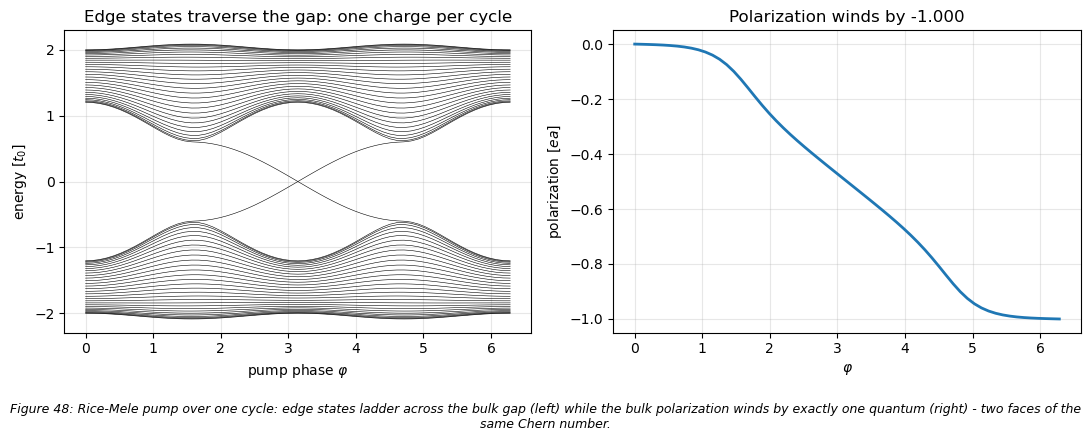

In [3]:
# --- Rice-Mele pump: Chern number, polarization flow, edge-state ladder -------
import kwant, numpy as np
from matplotlib import pyplot

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])
t0, d0, D0 = 1.0, 0.6, 0.6

def h_rice_mele(k, phi):
    t1 = t0 + d0 * np.cos(phi)
    t2 = t0 - d0 * np.cos(phi)
    D = D0 * np.sin(phi)
    q = t1 + t2 * np.exp(1j * k)
    return np.array([[D, q], [np.conj(q), -D]])

def chern_fhs(hfunc, n_occ, n1=40, n2=40):
    """Chern number by the Fukui-Hatsugai-Suzuki plaquette method.

    hfunc(x1, x2): Bloch Hamiltonian, 2pi-periodic in both arguments.  The
    result is exactly integer on any grid fine enough to resolve the gap.
    (Reused by every 2D section below.)
    """
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    frames = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            frames[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            u1 = link(frames[i, j], frames[(i+1) % n1, j])
            u2 = link(frames[(i+1) % n1, j], frames[(i+1) % n1, (j+1) % n2])
            u3 = link(frames[(i+1) % n1, (j+1) % n2], frames[i, (j+1) % n2])
            u4 = link(frames[i, (j+1) % n2], frames[i, j])
            F += np.angle(u1 * u2 * u3 * u4)
    return int(round(F / (2 * np.pi)))

C = chern_fhs(h_rice_mele, n_occ=1)
print(f"charge pumped per cycle = C over the (k, phi) torus = {C}")
assert abs(C) == 1

# a cycle that does NOT encircle the gapless point pumps nothing
def h_no_pump(k, phi):
    t1 = t0 + d0 * np.cos(phi)
    t2 = t0 - d0 * np.cos(phi)
    q = t1 + t2 * np.exp(1j * k)
    return np.array([[0, q], [np.conj(q), 0]])
print("cycle without onsite modulation:", chern_fhs(h_no_pump, n_occ=1))

# polarization (Zak phase) winds once per cycle -- same integer
def zak(phi, nk=200):
    ks = np.linspace(0, 2 * np.pi, nk, endpoint=False)
    us = [np.linalg.eigh(h_rice_mele(k, phi))[1][:, 0] for k in ks]
    prod = 1.0 + 0j
    for i in range(nk):
        prod *= np.vdot(us[i], us[(i + 1) % nk])
    return -np.angle(prod) / (2 * np.pi)

phis = np.linspace(0, 2 * np.pi, 61)
pol = np.unwrap([2 * np.pi * zak(p) for p in phis]) / (2 * np.pi)

# finite chain: the edge-state ladder carries the charge across the gap
lat = kwant.lattice.chain(norbs=2)
L = 30
def finite_chain(phi):
    t1 = t0 + d0 * np.cos(phi); t2 = t0 - d0 * np.cos(phi)
    D = D0 * np.sin(phi)
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = D * sigma_z + t1 * sigma_x
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = \
        t2 * np.array([[0, 1], [0, 0]])
    return syst.finalized()

spectra = np.array([np.linalg.eigvalsh(finite_chain(p).hamiltonian_submatrix())
                    for p in phis])

fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(11, 4))
ax1.plot(phis, spectra, 'k-', lw=.4)
ax1.set_xlabel(r"pump phase $\varphi$"); ax1.set_ylabel("energy $[t_0]$")
ax1.set_title("Edge states traverse the gap: one charge per cycle")
ax1.grid(alpha=.3)
ax2.plot(phis, pol, lw=2)
ax2.set_xlabel(r"$\varphi$"); ax2.set_ylabel("polarization $[ea]$")
ax2.set_title(f"Polarization winds by {pol[-1] - pol[0]:+.3f}")
ax2.grid(alpha=.3)
pyplot.tight_layout(); show_fig(r'Rice-Mele pump over one cycle: edge states ladder across the bulk gap (left) while the bulk polarization winds by exactly one quantum (right) - two faces of the same Chern number.')

assert abs(abs(pol[-1] - pol[0]) - 1) < 0.02

---
## 21. The Haldane model — a Chern insulator without Landau levels

Haldane [PRL **61**, 2015 (1988)] showed that the quantum Hall effect needs no
net magnetic field — only broken time-reversal symmetry.  Take graphene, add a
staggered sublattice potential $\pm M$ and complex second-neighbour hoppings
$t_2 e^{\pm i\phi}$ (the sign set by the chirality of the path):

$$H = t_1\!\!\sum_{\langle ij\rangle}\! c_i^\dagger c_j
    + t_2\!\!\sum_{\langle\langle ij\rangle\rangle}\!\! e^{i\nu_{ij}\phi}\, c_i^\dagger c_j
    + M\sum_i \xi_i\, c_i^\dagger c_i .$$

The phase diagram in $(\phi, M/t_2)$ contains lobes with Chern number
$C = \pm 1$ bounded by $|M| = 3\sqrt{3}\, t_2 \sin\phi$.  Consequences, all
verified below:

* $C$ computed by the FHS formula jumps between $0$ and $\pm 1$ exactly at the
  predicted boundary;
* a ribbon carries one **chiral** edge mode per edge crossing the bulk gap;
* the two-terminal conductance is quantized at $C\,e^2/h$ and — because a
  chiral mode has no backward channel to scatter into — *completely immune to
  disorder*.

(See topocondmat.org week 4; PythTB's `haldane_bp` example computes the same
Berry curvature.)

**Physics in more depth.**  Haldane's point was conceptual: the quantum Hall
effect requires broken time reversal, *not* a net magnetic field — Landau
levels are sufficient, never necessary.  The staggered flux enters only
through the phases $t_2e^{\pm i\phi}$; each hexagon still encloses zero
total flux.  At $M=0$, $\phi=0$ the model is graphene with two Dirac
points; the $M$ term gaps them with the *same* mass sign (trivial), the
$\phi$ term with *opposite* signs (topological) — the phase boundary is
where one Dirac mass changes sign, which is why it is $|M| =
3\sqrt{3}t_2\sin\phi$.

*Experiments:* the "quantum anomalous Hall effect" this model predicts was
observed in magnetically doped topological-insulator films [Chang *et al.*,
Science **340**, 167 (2013)], and the Haldane model itself was engineered
with shaken optical lattices [Jotzu *et al.*, Nature **515**, 237 (2014)].
See Haldane's Nobel lecture, RMP **89**, 040502 (2017).


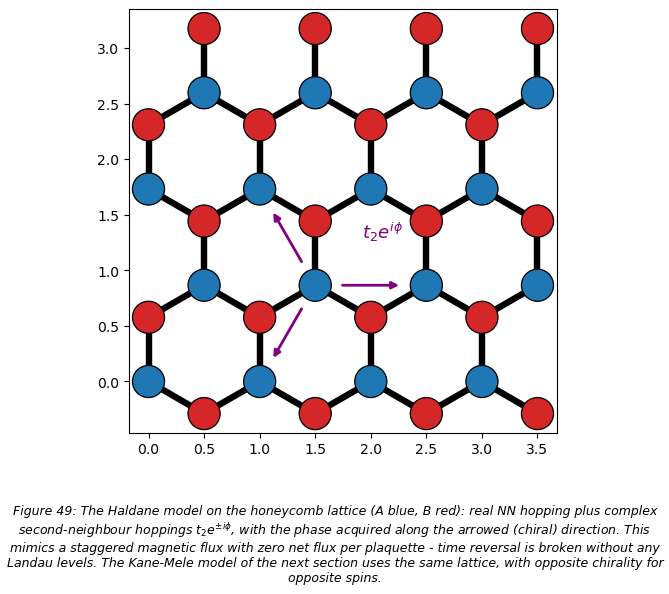

In [4]:
# --- geometry: honeycomb lattice with chiral second-neighbour hoppings -------
import kwant, numpy as np
from matplotlib import pyplot

lat_h = kwant.lattice.honeycomb(norbs=1)
asub, bsub = lat_h.sublattices
fl = kwant.Builder()
fl[lat_h.shape(lambda p: -0.5 < p[0] < 3.6 and -0.4 < p[1] < 3.2, (1, 1))] = 0
fl[lat_h.neighbors()] = -1
fig = kwant.plot(fl,
                 site_color=lambda s: '#1f77b4' if s.family == asub else '#d62728',
                 site_lw=0.02, fig_size=(6.5, 5.5), show=False)
ax = fig.get_axes()[0]
c = np.array(asub(1, 1).pos)
for v in [(1, 0), (-1, 1), (0, -1)]:
    d = np.array(asub(1 + v[0], 1 + v[1]).pos) - c
    ax.annotate('', xy=c + 0.78 * d, xytext=c + 0.22 * d,
                arrowprops=dict(arrowstyle='-|>', color='purple', lw=2))
ax.annotate(r'$t_2 e^{i\phi}$', xy=c + np.array([0.42, 0.42]),
            color='purple', fontsize=13)
show_fig(r'The Haldane model on the honeycomb lattice (A blue, B red): real NN hopping plus complex second-neighbour hoppings $t_2 e^{\pm i\phi}$, with the phase acquired along the arrowed (chiral) direction. This mimics a staggered magnetic flux with zero net flux per plaquette - time reversal is broken without any Landau levels. The Kane-Mele model of the next section uses the same lattice, with opposite chirality for opposite spins.')

M= 0.00, phi=+1.57:  C = +1   (centre of the C=+1 lobe)
M= 1.01, phi=+1.57:  C = +0   (above the lobe)


M= 0.00, phi=-1.57:  C = -1   (opposite chirality)


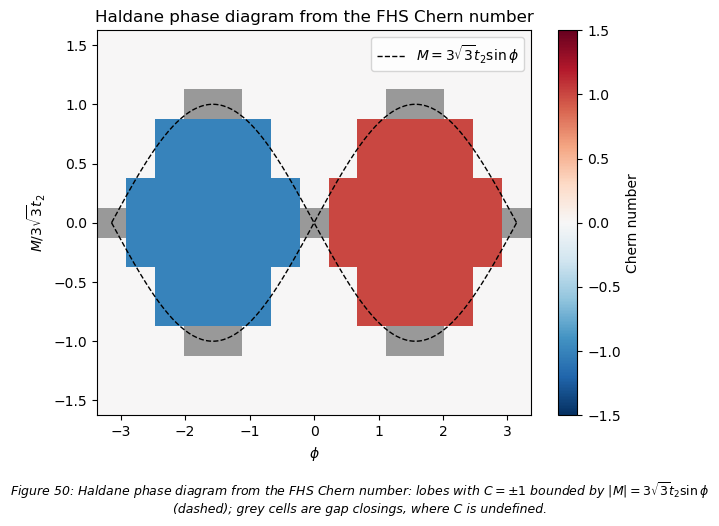

In [5]:
# --- Haldane model: Bloch Hamiltonian from kwant + Chern phase diagram --------
import kwant, kwant.wraparound, numpy as np
from matplotlib import pyplot

t1_h, t2_h = 1.0, 0.15
lat = kwant.lattice.honeycomb(norbs=1)
a_sub, b_sub = lat.sublattices
nnn_a = [kwant.builder.HoppingKind(v, a_sub, a_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]      # one chirality class
nnn_b = [kwant.builder.HoppingKind(v, b_sub, b_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]

def haldane_bulk(M, phi):
    syst = kwant.Builder(kwant.TranslationalSymmetry(*lat.prim_vecs))
    syst[a_sub(0, 0)] = M
    syst[b_sub(0, 0)] = -M
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    return syst

def bloch_hamiltonian(bulk_builder, prim_vecs):
    """H(theta1, theta2), theta_i = phase across primitive vector i.

    Works for any 2D lattice: wraparound gives H(k) in Cartesian momenta;
    mapping through the reciprocal vectors makes it 2pi-periodic in theta,
    which is what chern_fhs (section 20) expects.
    """
    wrapped = kwant.wraparound.wraparound(bulk_builder).finalized()
    b1, b2 = 2 * np.pi * np.linalg.inv(np.array(prim_vecs)).T
    def hfunc(th1, th2):
        k = (th1 * b1 + th2 * b2) / (2 * np.pi)
        return wrapped.hamiltonian_submatrix(params=dict(k_x=k[0], k_y=k[1]))
    return hfunc

Mc = 3 * np.sqrt(3) * t2_h
for M, phi, label in [(0.0, np.pi / 2, "centre of the C=+1 lobe"),
                      (1.3 * Mc, np.pi / 2, "above the lobe"),
                      (0.0, -np.pi / 2, "opposite chirality")]:
    C = chern_fhs(bloch_hamiltonian(haldane_bulk(M, phi), lat.prim_vecs),
                  n_occ=1, n1=24, n2=24)
    print(f"M={M:5.2f}, phi={phi:+.2f}:  C = {C:+d}   ({label})")

# the celebrated phase diagram, computed pointwise.  Two numerical caveats:
# the FHS grid must resolve the Berry-curvature hotspots at K and K' (16x16
# is NOT enough at M=0 -- it returns 0 there; 24x24 is), and at gapless
# points the Chern number is undefined, so mask them out.
def direct_gap(M, phi, n=30):
    # Two subtleties.  (1) Use the DIRECT gap E2(k)-E1(k), not min|E|: the
    # NNN term carries a sigma_0 offset that pushes bands through E=0 without
    # closing the direct gap, and only the direct gap matters for the Chern
    # number.  (2) A coarse k-grid can miss the Dirac point entirely (pure
    # graphene "shows" a gap of 0.15 on a 30x30 grid!), so refine locally
    # around the coarse minimum.
    hf = bloch_hamiltonian(haldane_bulk(M, phi), lat.prim_vecs)
    ks = np.linspace(0, 2 * np.pi, n, endpoint=False)
    gaps = np.array([[np.diff(np.linalg.eigvalsh(hf(x1, x2)))[0]
                      for x2 in ks] for x1 in ks])
    i, j = np.unravel_index(gaps.argmin(), gaps.shape)
    fine = np.linspace(-2 * np.pi / n, 2 * np.pi / n, 15)
    return min(np.diff(np.linalg.eigvalsh(hf(ks[i] + dx, ks[j] + dy)))[0]
               for dx in fine for dy in fine)

phis = np.linspace(-np.pi, np.pi, 15)
Ms = np.linspace(-1.5 * Mc, 1.5 * Mc, 13)
Cmap = np.full((len(Ms), len(phis)), np.nan)
for i, M in enumerate(Ms):
    for j, phi in enumerate(phis):
        if direct_gap(M, phi) > 0.05:
            Cmap[i, j] = chern_fhs(bloch_hamiltonian(haldane_bulk(M, phi),
                                                     lat.prim_vecs),
                                   n_occ=1, n1=24, n2=24)

cmap = pyplot.get_cmap('RdBu_r').copy()
cmap.set_bad('0.6')                       # grey = gap closed, C undefined
pyplot.pcolormesh(phis, Ms / Mc, Cmap, shading='auto', cmap=cmap,
                  vmin=-1.5, vmax=1.5)
pyplot.colorbar(label="Chern number")
ph = np.linspace(-np.pi, np.pi, 200)
pyplot.plot(ph, np.sin(ph) * np.ones_like(ph) * 1.0, 'k--', lw=1,
            label=r"$M = 3\sqrt{3}t_2\sin\phi$")
pyplot.plot(ph, -np.sin(ph), 'k--', lw=1)
pyplot.xlabel(r"$\phi$"); pyplot.ylabel(r"$M / 3\sqrt{3}t_2$")
pyplot.title("Haldane phase diagram from the FHS Chern number")
pyplot.legend(loc='upper right'); show_fig(r'Haldane phase diagram from the FHS Chern number: lobes with $C=\pm1$ bounded by $|M|=3\sqrt{3}t_2\sin\phi$ (dashed); grey cells are gap closings, where C is undefined.')

topological ($M = 0$):  $C = 1$:  integrated curvature / 2pi = +1.0000


trivial ($M = 1.3 M_c$):  $C = 0$:  integrated curvature / 2pi = -0.0000


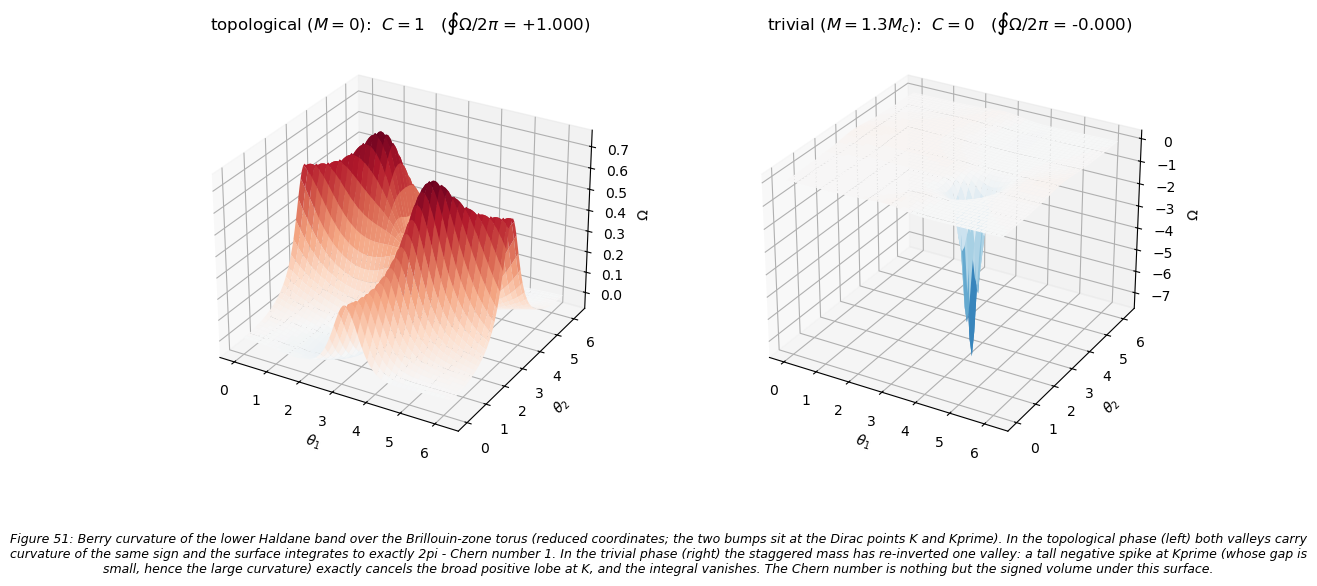

In [6]:
# --- Berry curvature of the Haldane model in 3D -------------------------------
# The Chern number is the integral of the Berry curvature over the BZ; here is
# the integrand itself, from the same plaquette construction as chern_fhs.
#
# One subtlety uncovered while writing this cell: kwant.wraparound's momenta
# k_x, k_y ARE the phases across the two primitive vectors (2pi-periodic as
# they stand).  The reciprocal-vector reparametrization used for the Chern
# numbers above is fine for the TOTAL flux (the loop closes combinatorially),
# but it is not 2pi-periodic point by point, which would contaminate the local
# curvature density along the torus seam.  So here we feed wraparound its own
# native coordinates.
def berry_curvature(bulk_builder, n=90):
    """Berry curvature density of the lowest band on the (theta1, theta2) torus."""
    w = kwant.wraparound.wraparound(bulk_builder).finalized()
    hf = lambda t1, t2: w.hamiltonian_submatrix(params=dict(k_x=t1, k_y=t2))
    th = np.linspace(0, 2 * np.pi, n, endpoint=False)
    u = np.empty((n, n), dtype=object)
    for a in range(n):
        for b in range(n):
            u[a, b] = np.linalg.eigh(hf(th[a], th[b]))[1][:, 0]
    F = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            F[a, b] = np.angle(
                np.vdot(u[a, b], u[(a + 1) % n, b]) *
                np.vdot(u[(a + 1) % n, b], u[(a + 1) % n, (b + 1) % n]) *
                np.vdot(u[(a + 1) % n, (b + 1) % n], u[a, (b + 1) % n]) *
                np.vdot(u[a, (b + 1) % n], u[a, b]))
    return th, F / (2 * np.pi / n) ** 2

fig = pyplot.figure(figsize=(13, 5.5))
for panel, (M, phi, label) in enumerate(
        [(0.0, np.pi / 2, r'topological ($M = 0$):  $C = 1$'),
         (1.3 * Mc, np.pi / 2, r'trivial ($M = 1.3 M_c$):  $C = 0$')]):
    th, Omega = berry_curvature(haldane_bulk(M, phi))
    C_int = Omega.sum() * (2 * np.pi / len(th)) ** 2 / (2 * np.pi)
    T1, T2 = np.meshgrid(th, th, indexing='ij')
    ax = fig.add_subplot(1, 2, panel + 1, projection='3d')
    ax.plot_surface(T1, T2, Omega, cmap='RdBu_r', linewidth=0,
                    antialiased=True,
                    vmin=-np.abs(Omega).max(), vmax=np.abs(Omega).max())
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_zlabel(r'$\Omega$')
    ax.set_title(rf'{label}   ($\oint\Omega/2\pi$ = {C_int:+.3f})')
    ax.view_init(elev=28, azim=-60)
    print(f'{label}:  integrated curvature / 2pi = {C_int:+.4f}')
    assert abs(C_int - round(C_int)) < 1e-6    # exactly integer on the torus
show_fig(r'Berry curvature of the lower Haldane band over the Brillouin-zone torus (reduced coordinates; the two bumps sit at the Dirac points K and Kprime). In the topological phase (left) both valleys carry curvature of the same sign and the surface integrates to exactly 2pi - Chern number 1. In the trivial phase (right) the staggered mass has re-inverted one valley: a tall negative spike at Kprime (whose gap is small, hence the large curvature) exactly cancels the broad positive lobe at K, and the integral vanishes. The Chern number is nothing but the signed volume under this surface.')

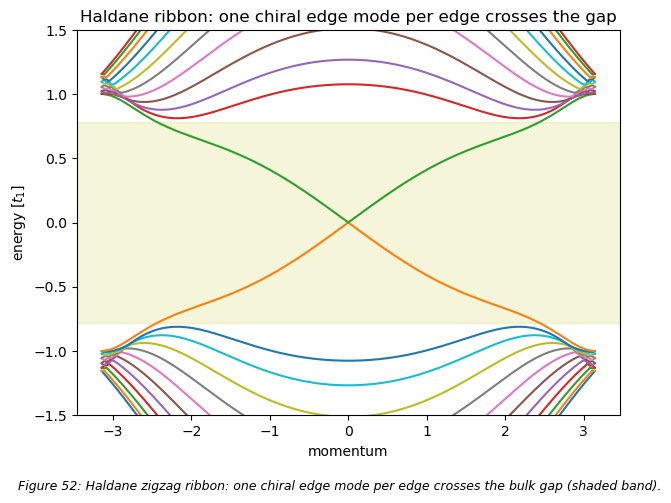

disorder U0=0.0:  T = 1.000000   (chiral edge: no backscattering)
disorder U0=0.3:  T = 0.999985   (chiral edge: no backscattering)


disorder U0=0.6:  T = 0.999960   (chiral edge: no backscattering)


In [7]:
# --- Haldane: chiral edge states and disorder-proof conductance ---------------
import kwant, numpy as np
from matplotlib import pyplot

def haldane_ribbon(M, phi, W=12):
    syst = kwant.Builder(kwant.TranslationalSymmetry(lat.vec((1, 0))))
    syst[lat.shape(lambda p: 0 <= p[1] < W * np.sqrt(3) / 2, (0, 0))] = \
        lambda s: M if s.family == a_sub else -M
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    return syst

frib = haldane_ribbon(0.0, np.pi / 2).finalized()
fig, ax = pyplot.subplots()
kwant.plotter.bands(frib, momenta=np.linspace(-np.pi, np.pi, 201), ax=ax)
ax.set_ylim(-1.5, 1.5)
ax.axhspan(-Mc, Mc, color='y', alpha=.15)
ax.set_xlabel("momentum"); ax.set_ylabel("energy $[t_1]$")
ax.set_title("Haldane ribbon: one chiral edge mode per edge crosses the gap")
show_fig(r'Haldane zigzag ribbon: one chiral edge mode per edge crosses the bulk gap (shaded band).')

def haldane_bar(M, phi, W=10, L=16, U0=0.0, salt="a"):
    syst = kwant.Builder()
    shape = lambda p: (0 <= p[0] < L) and (0 <= p[1] < W * np.sqrt(3) / 2)
    def onsite(s):
        m = M if s.family == a_sub else -M
        return m + U0 * (kwant.digest.uniform(repr(s.tag) + s.family.name,
                                              salt) - 0.5)
    syst[lat.shape(shape, (0, 0))] = onsite
    syst[lat.neighbors()] = t1_h
    for kind in nnn_a:
        syst[kind] = t2_h * np.exp(1j * phi)
    for kind in nnn_b:
        syst[kind] = t2_h * np.exp(-1j * phi)
    syst.eradicate_dangling()
    lead = haldane_ribbon(M, phi, W=W)
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.15                                        # inside the bulk gap
for U0 in (0.0, 0.3, 0.6):
    T = kwant.smatrix(haldane_bar(0.0, np.pi / 2, U0=U0), E).transmission(1, 0)
    print(f"disorder U0={U0}:  T = {T:.6f}   (chiral edge: no backscattering)")
    assert abs(T - 1.0) < 1e-3